In [2]:
import sqlite3
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import Markdown


In [2]:
db_path = Path(Path.cwd().parent) / "db/chinook.db"
conn = sqlite3.connect(db_path)

In [3]:
def get_data(sql: str) -> pd.DataFrame:
    """Get data."""
    return pd.read_sql_query(sql, conn)

def display_data(data: pd.DataFrame, head: bool | int = False) -> None:
    """Display data."""
    if head:
        display(Markdown(data.head(head).to_markdown(index=False)))
    else:
        display(Markdown(data.to_markdown(index=False)))

In [4]:
sql = """SELECT
    STRFTIME('%Y-%m', i.InvoiceDate) AS InvoiceYear,
    COUNT(c.CustomerId) AS Customers,
    COUNT(i.InvoiceId) AS Invoices,
    SUM(i.Total) AS Total
FROM Employee e
RIGHT JOIN Customer c ON c.SupportRepId = e.EmployeeId
LEFT JOIN Invoice i ON i.CustomerId = c.CustomerId
GROUP BY STRFTIME('%Y-%m', i.InvoiceDate)
ORDER BY InvoiceYear DESC, Total DESC;
"""
display_data(data:=get_data(sql), 5)

| InvoiceYear   |   Customers |   Invoices |   Total |
|:--------------|------------:|-----------:|--------:|
| 2025-12       |           7 |          7 |   38.62 |
| 2025-11       |           7 |          7 |   49.62 |
| 2025-10       |           7 |          7 |   37.62 |
| 2025-09       |           7 |          7 |   37.62 |
| 2025-08       |           7 |          7 |   37.62 |

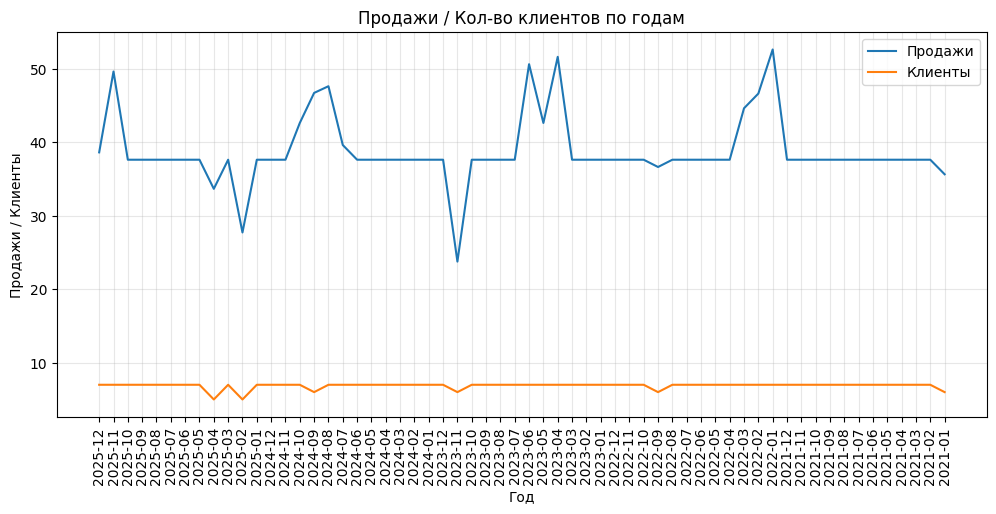

In [5]:
plt.figure(figsize=(12, 5))
plt.plot(data["InvoiceYear"], data["Total"], label="Продажи")
plt.plot(data["InvoiceYear"], data["Customers"], label="Клиенты")

plt.xticks(rotation="vertical")
plt.grid(True, alpha=0.3)
plt.xlabel("Год")
plt.ylabel("Продажи / Клиенты")
plt.title("Продажи / Кол-во клиентов по годам")
plt.legend()

plt.show()